In [34]:
import numpy as np, matplotlib.pyplot as plt

files = ["Mystery1.csv", "Mystery2.data", "Mystery3.data", "Mystery4.data", "Mystery5.data"]

In [35]:
for f in files:
    a = np.loadtxt(f, delimiter=",")
    print(f"{f:16} shape={str(a.shape):14} "
          f"min={a.min():>10.3g} max={a.max():>10.3g} "
          f"mean={a.mean():>10.3g} distinct={len(np.unique(a))}")

Mystery1.csv     shape=(500, 500)     min=         1 max=     1e+03 mean=       221 distinct=406
Mystery2.data    shape=(762, 602)     min=         1 max=       250 mean=        76 distinct=228
Mystery3.data    shape=(1472, 1156)   min=         0 max=        63 mean=      32.6 distinct=64
Mystery4.data    shape=(500, 500)     min=         2 max=     1e+03 mean=      91.4 distinct=527
Mystery5.data    shape=(500, 501)     min=         0 max=       755 mean=       168 distinct=381


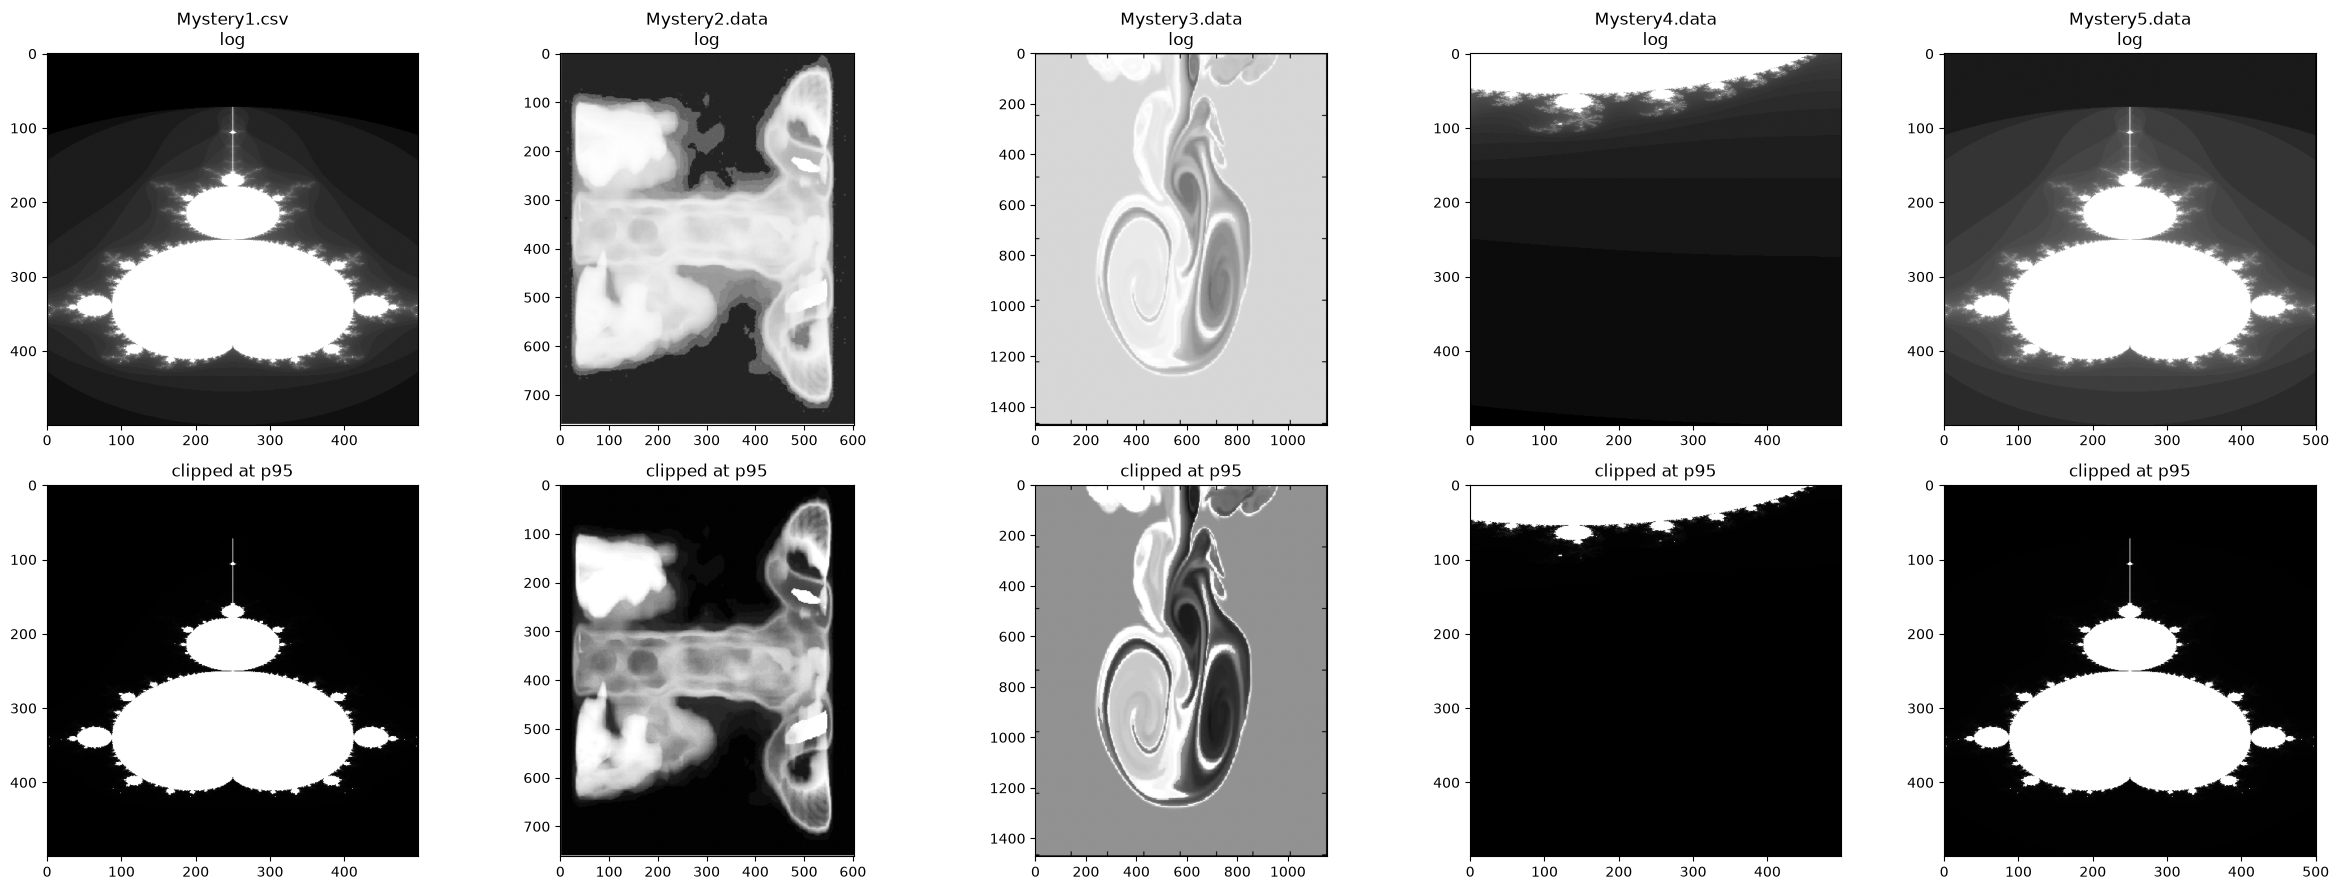

In [36]:
CMAP = "gray"

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
for i, f in enumerate(files):
    a = np.loadtxt(f, delimiter=",")
    axes[0,i].imshow(np.log1p(a), cmap=CMAP)
    axes[0,i].set_title(f"{f}\nlog")
    axes[1,i].imshow(a, vmax=np.percentile(a, 95), cmap=CMAP)
    axes[1,i].set_title("clipped at p95")
plt.tight_layout(); plt.show()

The output produced above maps the data to a heatmap with the grayscale as the color scheme.

In [37]:
from PIL import Image

def create_show_image(rgb, f):
    img = Image.fromarray(rgb)
    img.save(f.rsplit(".", 1)[0] + ".png")
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f)
    plt.axis("off")
    plt.show()

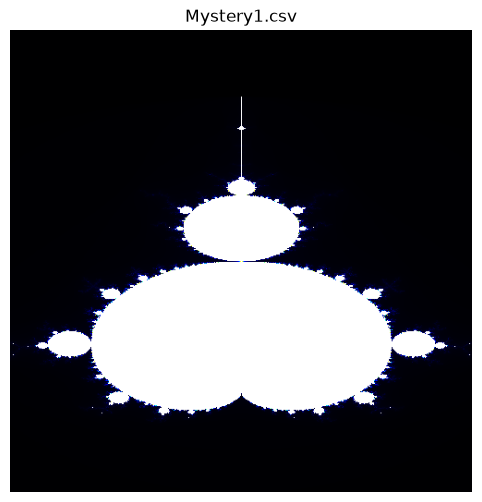

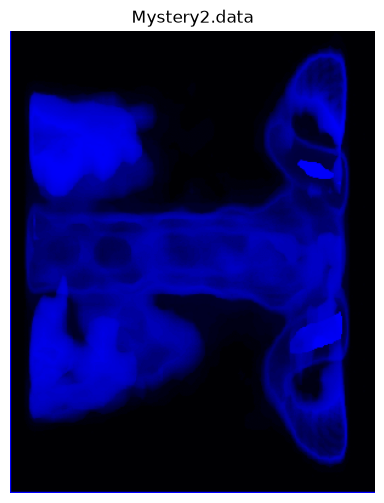

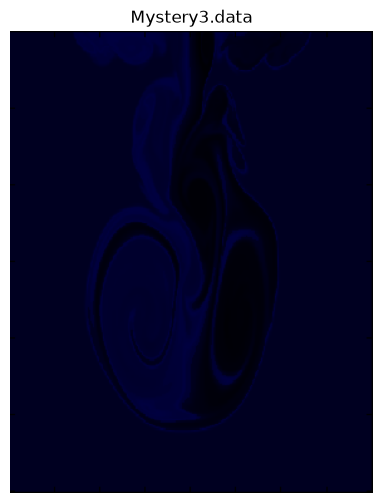

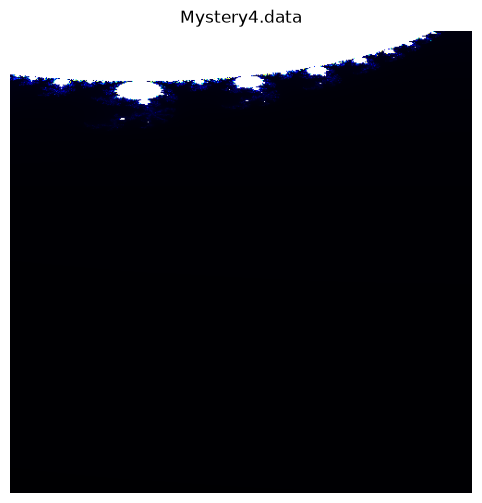

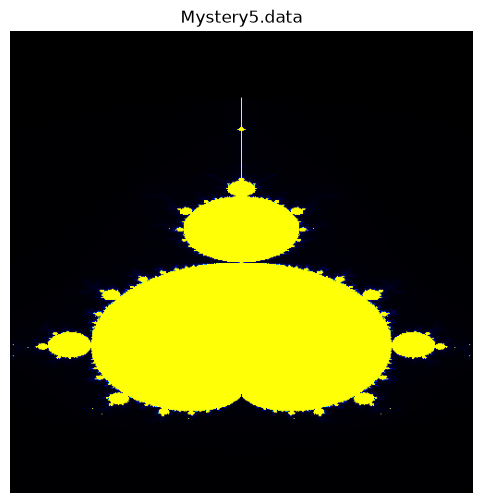

In [38]:
for f in files:
    a = np.loadtxt(f, delimiter=",")
    
    # Divide by 1000 to normalize values to make life easier in RGB calculations
    t = np.clip(a / 1000.0, 0, 1)
    
    r = np.clip(4 * t - 2, 0, 1)
    g = np.clip(4 * t - 1, 0, 1)
    b = (
        np.clip(4 * t, 0, 1)
        - np.clip(4 * t - 2, 0, 1)
        + np.clip(4 * t - 3, 0, 1)
    )

    rgb = np.round(
        255 * np.stack([r, g, b], axis=-1)
    ).astype(np.uint8)
    
    create_show_image(rgb, f)

    

The above generates images but the color range is not wide enough at all, not even close. 

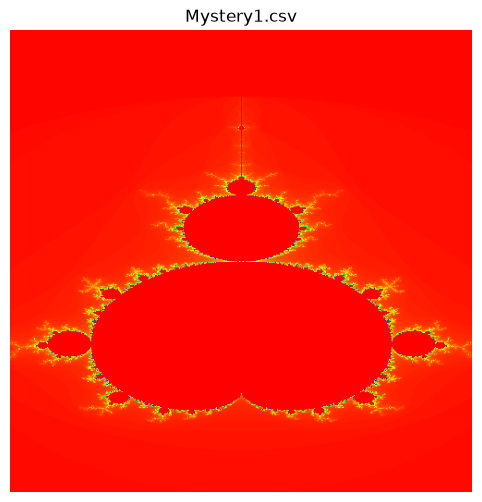

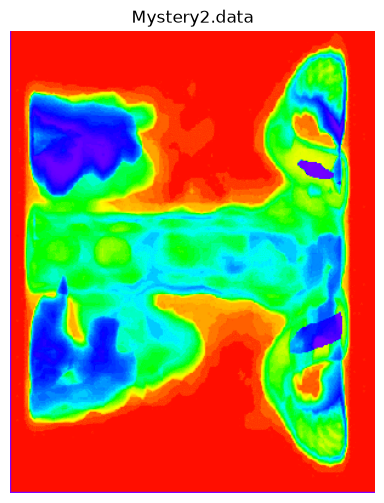

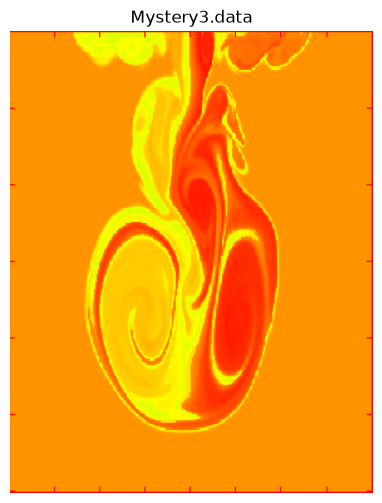

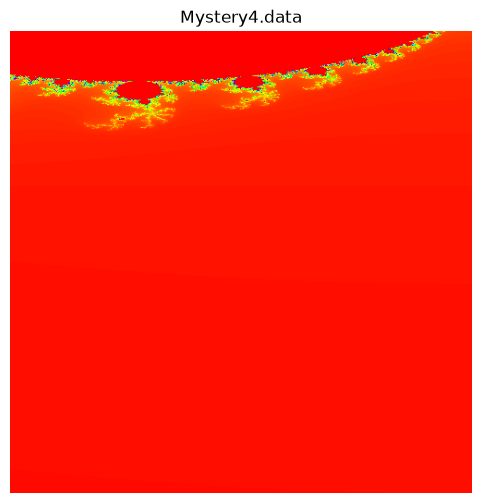

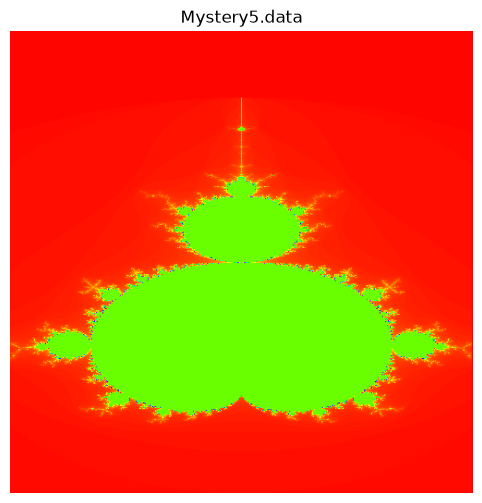

In [39]:
from matplotlib.colors import hsv_to_rgb

for f in files:
    a = np.loadtxt(f, delimiter=",")
    
    # Divide by 1000 to normalize values to make life easier in RGB calculations
    t = np.clip(a / 1000.0, 0, 1)
    
    hue = (3 * t) % 1.0
    saturation = np.ones_like(t)
    brightness = np.ones_like(t)

    hsv = np.stack([hue, saturation, brightness], axis=-1)
    rgb = np.round(255 * hsv_to_rgb(hsv)).astype(np.uint8)
    
    create_show_image(rgb, f)

    

This approach of getting a hue and turning that to RGB is closer. It gets that rainbow look on the edges that I'm looking for but I don't think the center or the background are correct.

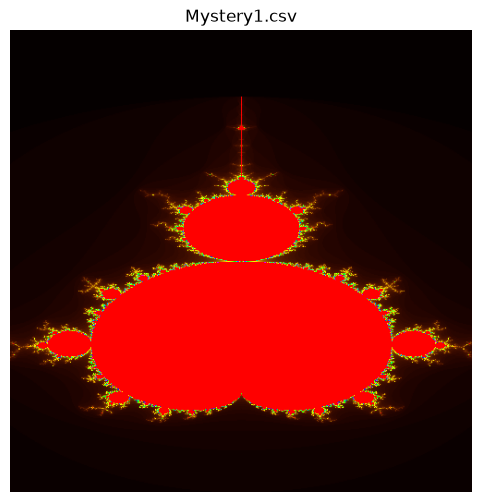

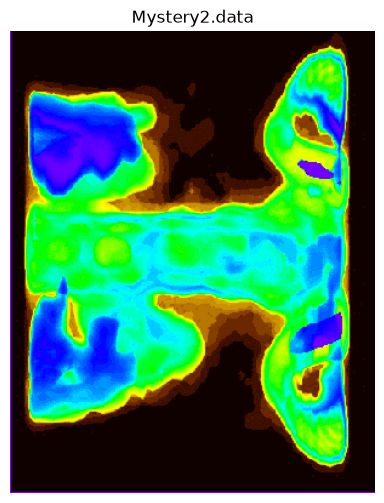

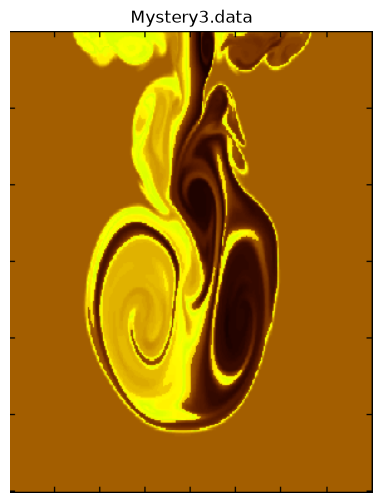

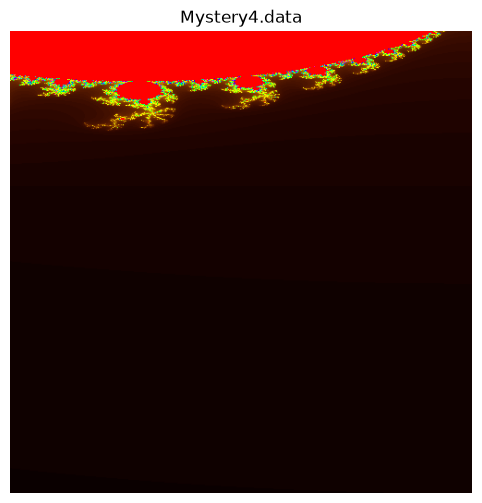

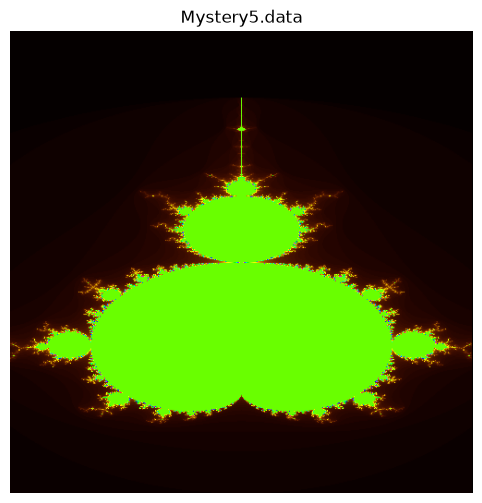

In [40]:
for f in files:
    a = np.loadtxt(f, delimiter=",")
    
    t = np.clip(a / 1000.0, 0, 1)
    
    hue = (3 * t) % 1.0
    saturation = np.ones_like(t)
    brightness = np.clip(t / 0.05, 0, 1) 
       
    hsv = np.stack([hue, saturation, brightness], axis=-1)
    rgb = np.round(255 * hsv_to_rgb(hsv)).astype(np.uint8)
    
    create_show_image(rgb, f)

This is definitely closer to what I was looking for, turns out changing the brightness makes a difference. I still am not sure if the center values are 100% correct so changing some more values might help me figure out that problem.

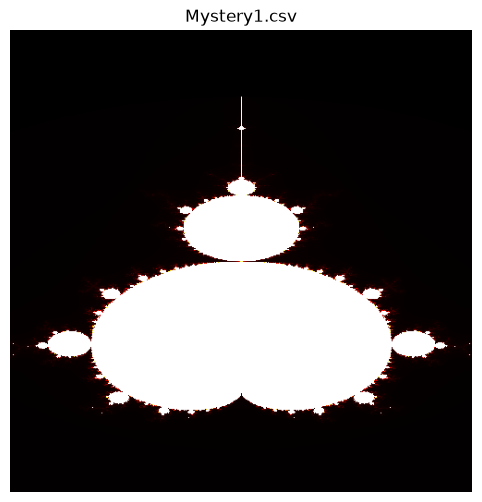

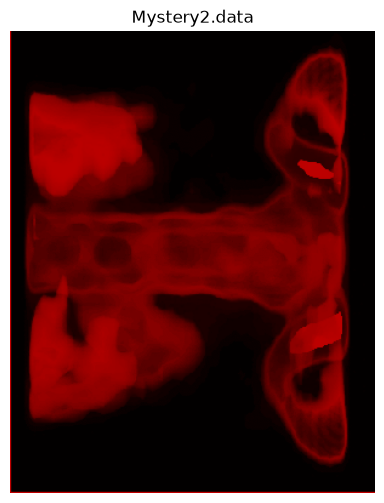

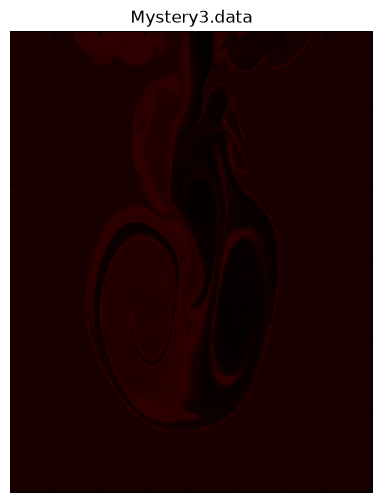

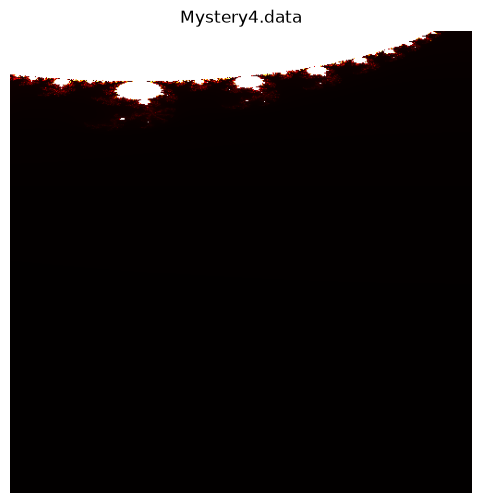

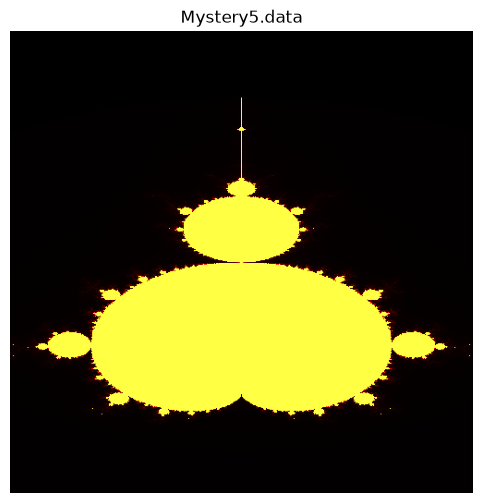

In [41]:
for f in files:
    a = np.loadtxt(f, delimiter=",")

    # Transform 0–1000 into 0–765.
    scaled = np.clip(a / 1000.0, 0, 1) * 765

    r = np.clip(scaled, 0, 255)
    g = np.clip(scaled - 255, 0, 255)
    b = np.clip(scaled - 510, 0, 255)

    rgb = np.round(
        np.stack([r, g, b], axis=-1)
    ).astype(np.uint8)

    create_show_image(rgb, f)

Trying an idea I thought of where the rgb is filled one color at a time but that doesnt really produce the result I am looking for.

The previous results is what I'm looking for except the 1000s are appearing red when they probably should be black.

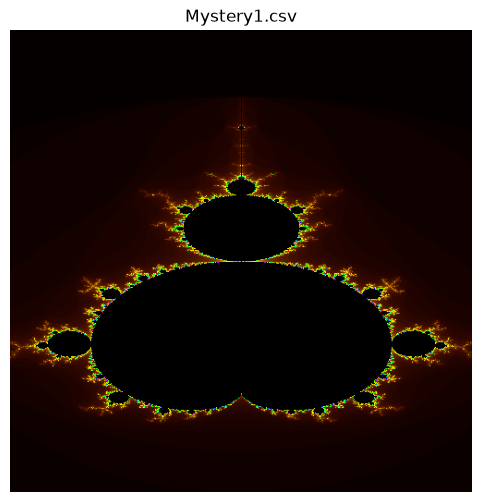

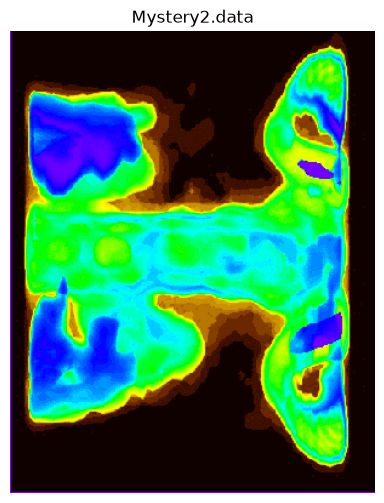

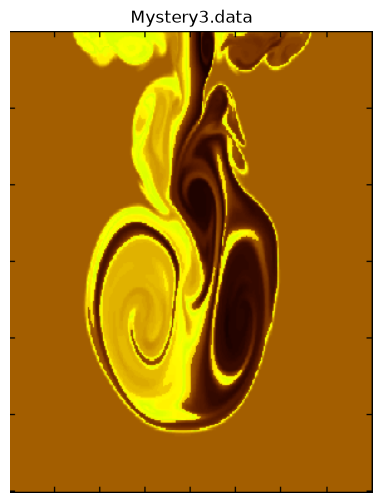

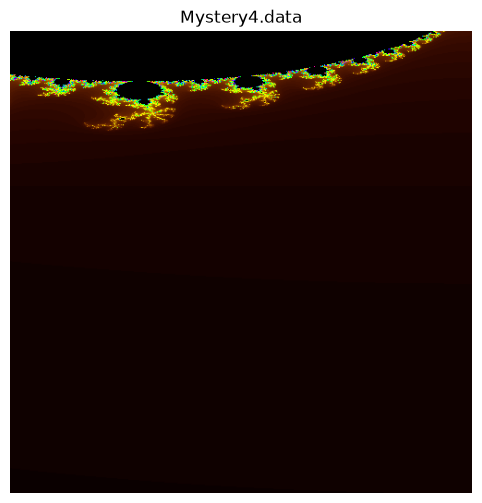

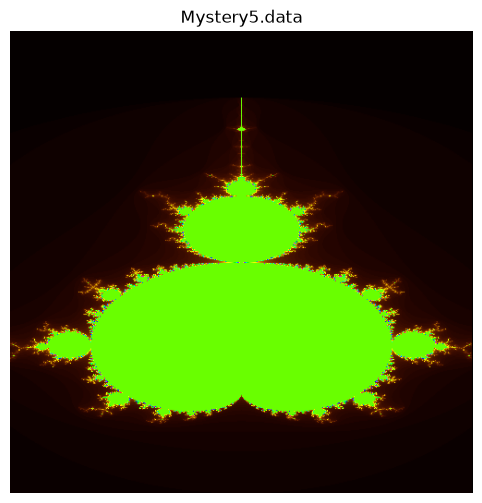

In [ ]:
from matplotlib.colors import hsv_to_rgb

for f in files:
    a = np.loadtxt(f, delimiter=",")
    
    # Divide by 1000 to normalize values to make life easier in RGB calculations
    t = np.clip(a / 1000.0, 0, 1)
    
    # Messing with hsv values to make color mapping more gradual, these produce an image that resembles what I'm trying to recreate
    hue = (3 * t) % 1.0
    saturation = np.ones_like(t)
    brightness = np.clip(
    np.minimum(t, 1 - t) / 0.05,
    0,
    1
)

    hsv = np.stack([hue, saturation, brightness], axis=-1)
    rgb = np.round(255 * hsv_to_rgb(hsv)).astype(np.uint8)
    
    create_show_image(rgb, f)

    

It was a brightness issue. The error was fixed.

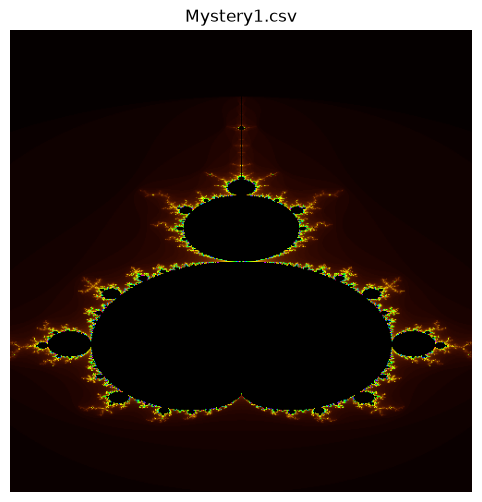

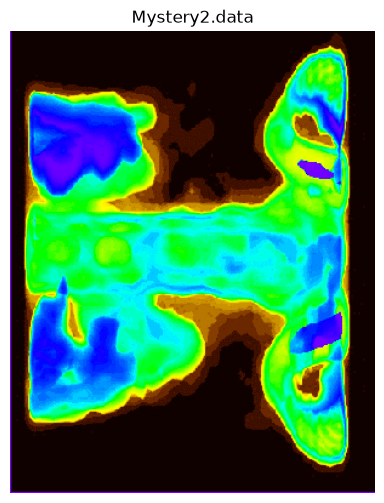

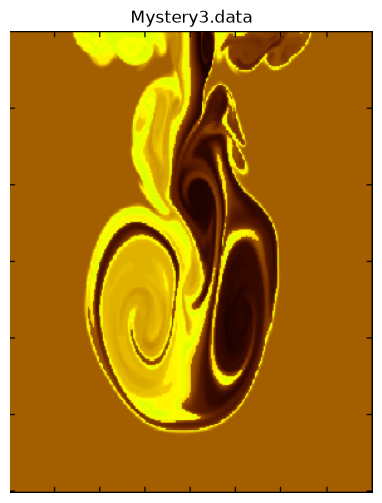

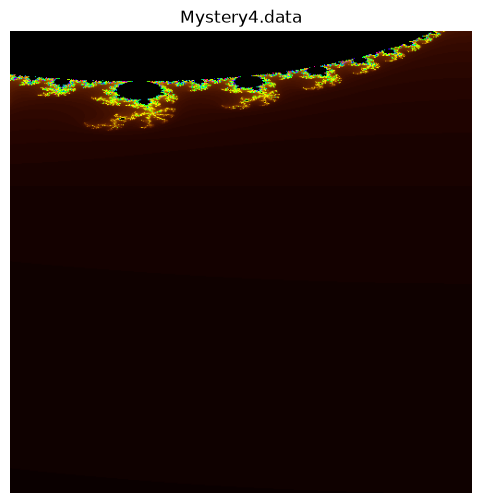

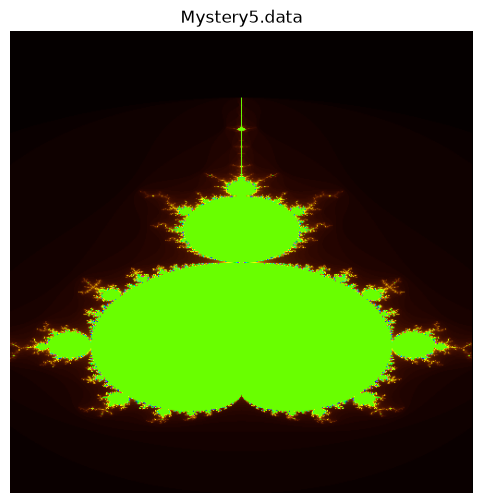

In [ ]:
for f in files:
    a = np.loadtxt(f, delimiter=",")
    t = np.clip(a / 1000.0, 0, 1)

    p = (18 * t) % 6

    fade = np.clip(np.minimum(t, 1 - t) / 0.05, 0, 1)

    r = np.clip(np.abs(p - 3) - 1, 0, 1)
    g = np.clip(2 - np.abs(p - 2), 0, 1)
    b = np.clip(2 - np.abs(p - 4), 0, 1)

    rgb = np.round(
        255 * fade[..., None] * np.stack([r, g, b], axis=-1)
    ).astype(np.uint8)

    create_show_image(rgb, f)